<a href="https://colab.research.google.com/github/HanaaMaswada/Prediction-of-Product-Sales/blob/main/Project_1(Core).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv')

In [4]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


1) How many rows and columns?

In [6]:
df.shape

(8523, 12)

In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 8523
Number of columns: 12


2) What are the datatypes of each variable?

In [8]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,object
Outlet_Location_Type,object


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


3) Are there duplicates? If so, drop any duplicates.

In [10]:
df.duplicated().sum()

np.int64(0)

4) Identify missing values

In [11]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,1463
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,2410
Outlet_Location_Type,0


5) Address the missing values using a placeholder value

In [12]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
df[num_cols] = df[num_cols].fillna(0)

In [13]:
cat_cols = df.select_dtypes(include=['object']).columns
df[cat_cols] = df[cat_cols].fillna("Unknown")

6) Confirm no missing values remain

In [14]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


7) Fix inconsistent categories

In [15]:
df['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular', 'low fat', 'LF', 'reg'], dtype=object)

In [16]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'low fat': 'Low Fat',
    'LF': 'Low Fat',
    'reg': 'Regular'
})

In [17]:
df['Item_Fat_Content'].unique()

array(['Low Fat', 'Regular'], dtype=object)

8) Summary statistics (min, max, mean)

In [18]:
df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,8523.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,10.650590,0.066132,140.992782,1997.831867,2181.288914
std,6.431899,0.051598,62.275067,8.371760,1706.499616
min,0.000000,0.000000,31.290000,1985.000000,33.290000
25%,6.650000,0.026989,93.826500,1987.000000,834.247400
50%,11.000000,0.053931,143.012800,1999.000000,1794.331000
75%,16.000000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [19]:
df.select_dtypes(include=['int64','float64']).agg(['min','max','mean'])

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
min,0.00000,0.000000,31.290000,1985.000000,33.290000
max,21.35000,0.328391,266.888400,2009.000000,13086.964800
mean,10.65059,0.066132,140.992782,1997.831867,2181.288914


Project 1 - Part 3

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

##Histogram

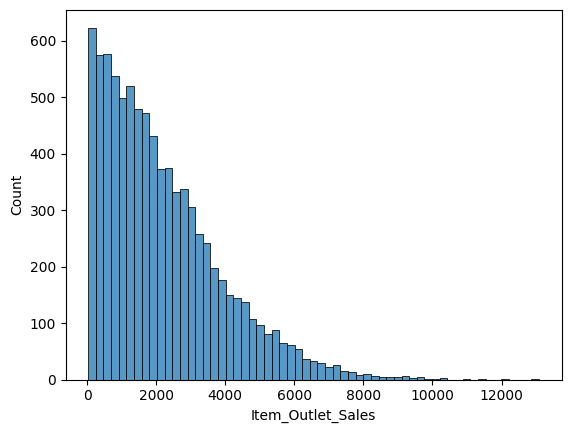

In [21]:
sns.histplot(df['Item_Outlet_Sales'])
plt.show()

##Boxplot

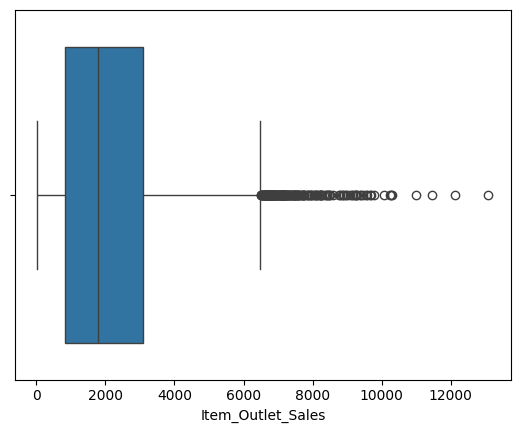

In [22]:
sns.boxplot(x=df['Item_Outlet_Sales'])
plt.show()

##Countplot

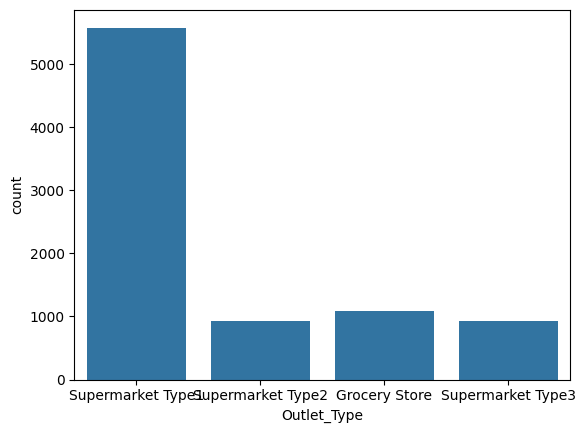

In [23]:
sns.countplot(x=df['Outlet_Type'])
plt.show()

##Heatmap

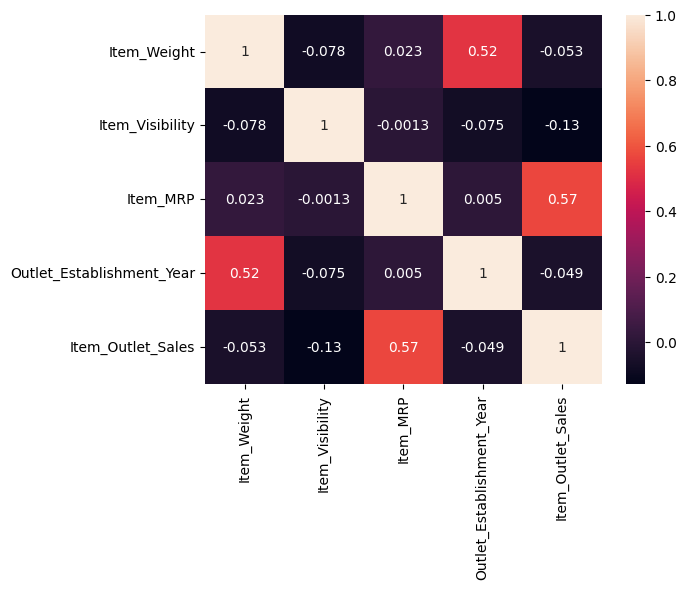

In [24]:
corr = df.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(corr, annot=True)
plt.show()

## Feature: Item_Weight

Represents the weight of the item.

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

def explore_numeric(df, x):
    fig, axes = plt.subplots(2, 1, figsize=(6,5), sharex=True)

    sns.histplot(data=df, x=x, ax=axes[0])
    sns.boxplot(data=df, x=x, ax=axes[1])

    axes[0].set_title(f"Column: {x}", fontweight='bold')
    plt.tight_layout()
    plt.show()

    null_count = df[x].isna().sum()
    null_perc = null_count / len(df) * 100

    print(f"NaN's Found: {null_count} ({round(null_perc,2)}%)")
    print(f"Unique Values: {df[x].nunique()}")

In [26]:
#numeric vs target
def plot_numeric_vs_target(df, x, y='Item_Outlet_Sales'):
    corr = df[[x,y]].corr().round(2)
    r = corr.loc[x,y]

    sns.regplot(data=df, x=x, y=y)
    plt.title(f"{x} vs {y} (r = {r})")
    plt.show()

In [27]:
#categorical
def explore_categorical(df, x):
    sns.countplot(data=df, x=x)
    plt.xticks(rotation=45)
    plt.title(f"Column: {x}")
    plt.show()

    print(f"NaN's Found: {df[x].isna().sum()}")
    print(f"Unique Values: {df[x].nunique()}")

In [28]:
#categorical vs target
def plot_categorical_vs_target(df, x, y='Item_Outlet_Sales'):
    sns.barplot(data=df, x=x, y=y)
    plt.xticks(rotation=45)
    plt.title(f"{x} vs {y}")
    plt.show()

In [29]:
df.replace(0, np.nan, inplace=True)
df.replace("Unknown", np.nan, inplace=True)

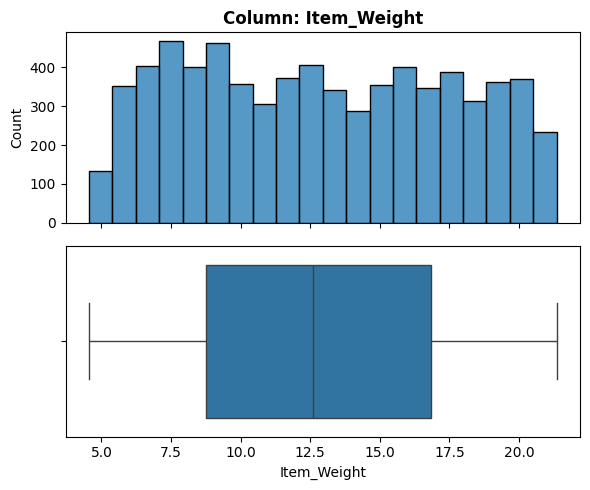

NaN's Found: 1463 (17.17%)
Unique Values: 415


In [30]:
explore_numeric(df, 'Item_Weight')

Outlet_Size

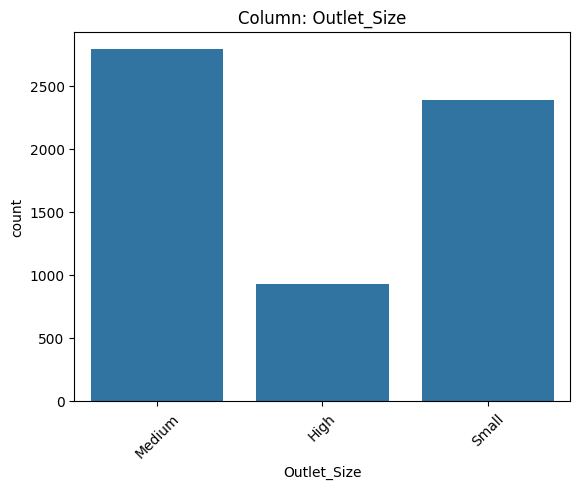

NaN's Found: 2410
Unique Values: 3


In [31]:
explore_categorical(df, 'Outlet_Size')

### Feature Observations:

- Type:
  Categorical

- Null values:
  There are 2410 missing values (~28% of the data).
  Since this is a categorical feature, I would impute the missing values using the most frequent category or keep them as a separate category (e.g., "Missing").

- Constant or quasi-constant:
  No, the values are distributed across three categories.

- Cardinality:
  Low (3 categories: Small, Medium, High)

- Known before target?
  Yes, outlet size is known before sales occur.

- Business reason to exclude?
  No, outlet size is an important factor that can influence sales.

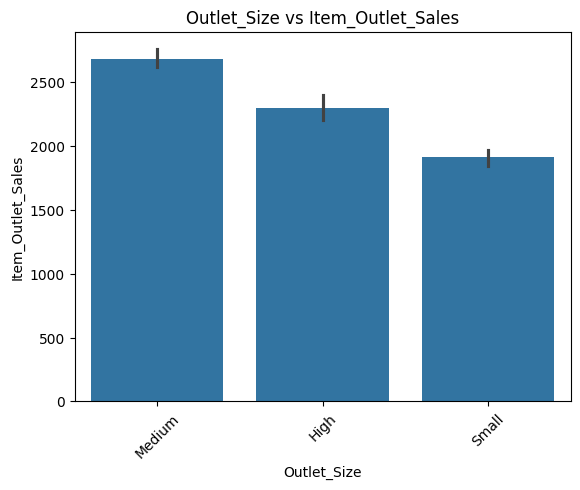

In [32]:
plot_categorical_vs_target(df, 'Outlet_Size', y='Item_Outlet_Sales')

### Feature vs Target Observations:

- Expected to predict target?
  Yes, outlet size is expected to influence sales.

- Does it appear to be a predictor?
  Yes, there is a clear difference in average sales across outlet sizes.

- Explanation:
  Medium outlets have the highest average sales, followed by High, while Small outlets have the lowest sales.
  This indicates that outlet size has a noticeable impact on sales and can be considered a useful predictor.

Item_MRP

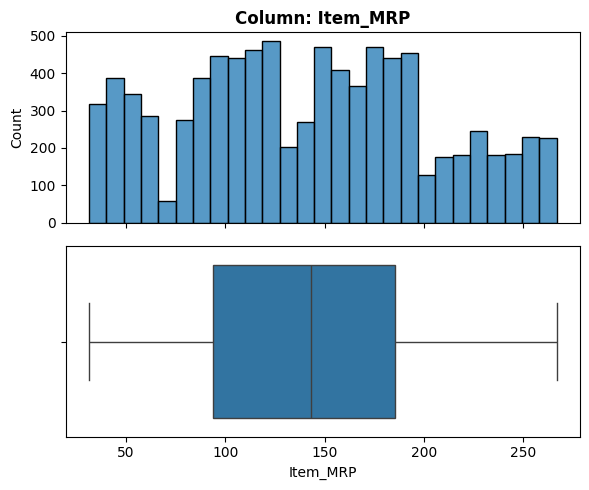

NaN's Found: 0 (0.0%)
Unique Values: 5938


In [33]:
explore_numeric(df, 'Item_MRP')

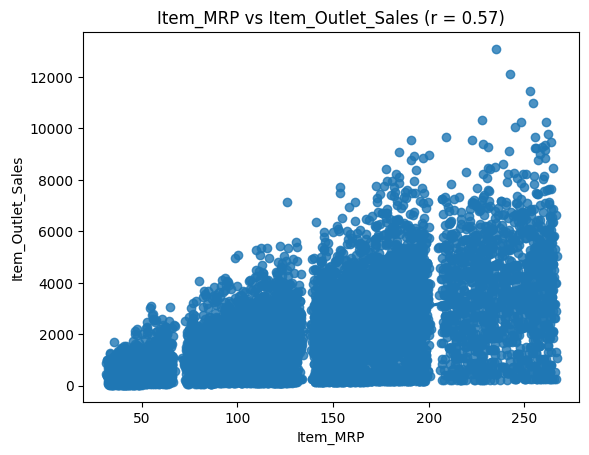

In [34]:
plot_numeric_vs_target(df, 'Item_MRP', y='Item_Outlet_Sales')

### Feature Observations:

- Type:
  Numeric

- Null values:
  There are no missing values (0%).

- Constant or quasi-constant:
  No, the values are well distributed across a wide range.

- Cardinality:
  High (many unique values: 5938)

- Known before target?
  Yes, the item price is known before sales occur.

- Business reason to exclude?
  No, item price is a key factor that directly affects sales.

### Feature vs Target Observations:

- Expected to predict target?
  Yes, higher priced items are expected to generate higher sales.

- Does it appear to be a predictor?
  Yes, there is a strong positive relationship.

- Explanation:
  The scatter plot shows a clear upward trend, and the correlation coefficient (r = 0.57) indicates a strong positive relationship.
  This means that as the item price increases, the sales tend to increase as well.
  Therefore, Item_MRP is one of the most important predictors of Item_Outlet_Sales.

Item_MRP appears to be one of the strongest predictors in the dataset and will likely have a significant impact on model performance.

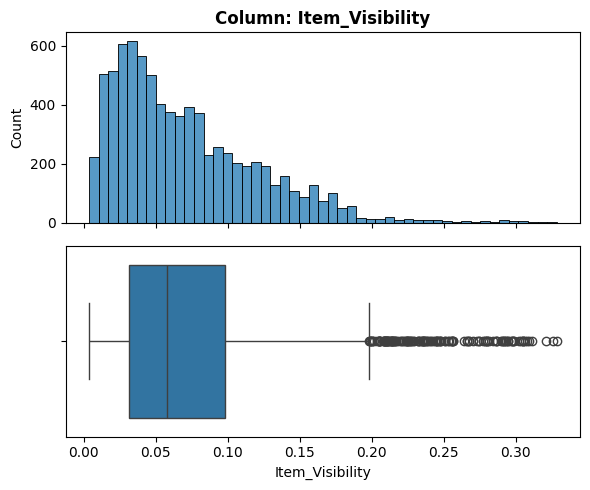

NaN's Found: 526 (6.17%)
Unique Values: 7879


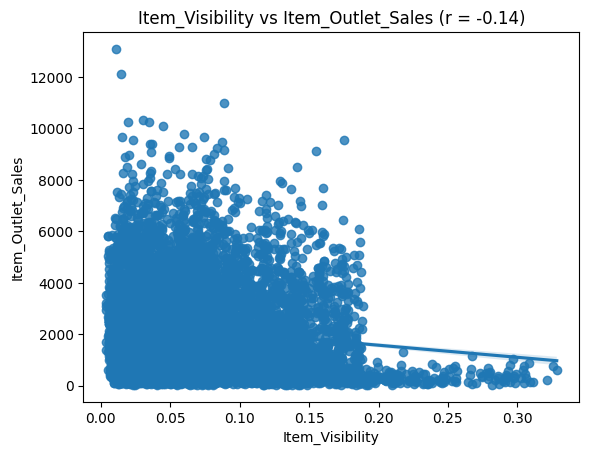

In [35]:
explore_numeric(df, 'Item_Visibility')
plot_numeric_vs_target(df, 'Item_Visibility', y='Item_Outlet_Sales')

### Feature Observations:

- Type:
  Numeric

- Null values:
  There are 526 missing values (~6.17%).

- Handling null values:
  Instead of dropping rows, we can impute missing values using the median since the data is skewed.

- Constant or quasi-constant:
  No, the feature has a wide distribution of values.

- Cardinality:
  High (many unique values: 7879)

- Known before target?
  Yes, item visibility is determined before sales occur.

- Business reason to exclude?
  No, visibility is an important business factor affecting sales.

### Feature vs Target Observations:

- Expected to predict target?
  Yes, higher visibility might lead to higher sales.

- Does it appear to be a predictor?
  Weak predictor.

- Explanation:
  The scatter plot shows a very weak negative relationship (r = -0.14).
  This suggests that higher visibility does not strongly increase sales and may even slightly decrease it.
  The data is highly scattered with no clear trend, indicating low predictive power.

Item_Visibility may have limited impact on the model and might require feature engineering or transformation to improve its usefulness.

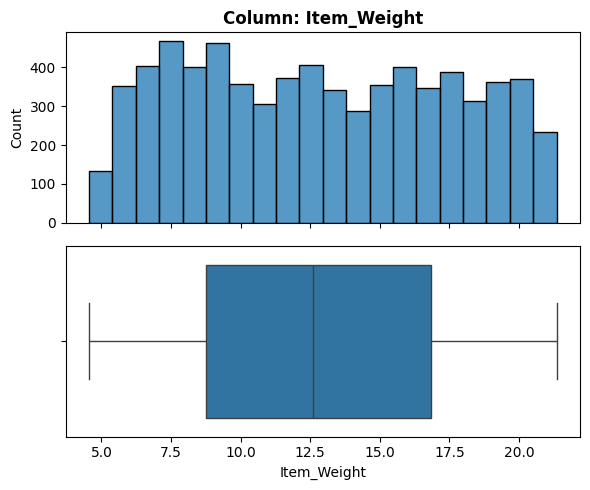

NaN's Found: 1463 (17.17%)
Unique Values: 415


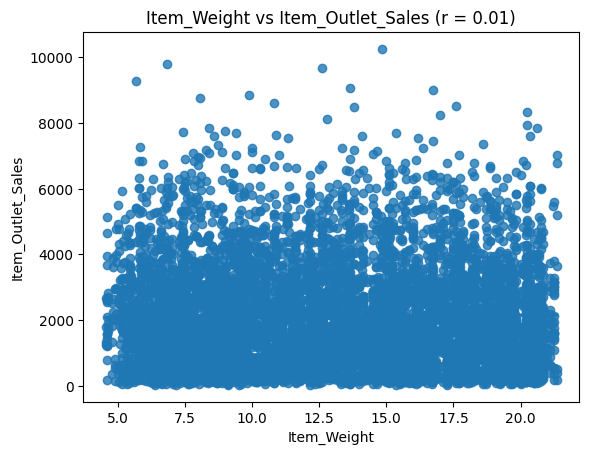

In [36]:
explore_numeric(df, 'Item_Weight')
plot_numeric_vs_target(df, 'Item_Weight', y='Item_Outlet_Sales')

### Feature Observations:

- Type:
  Numeric

- Null values:
  There are 1463 missing values (~17.17%).

- Handling null values:
  We should impute missing values using the median because the distribution is fairly spread and median is robust to outliers.

- Constant or quasi-constant:
  No, the feature has a wide range of values.

- Cardinality:
  Moderate (415 unique values)

- Known before target?
  Yes, item weight is known before sales occur.

- Business reason to exclude?
  No, weight could influence packaging, pricing, and logistics, so it may indirectly affect sales.

### Feature vs Target Observations:

- Expected to predict target?
  Possibly, but not strongly.

- Does it appear to be a predictor?
  No, very weak predictor.

- Explanation:
  The scatter plot shows almost no relationship between Item_Weight and Item_Outlet_Sales (r = 0.01).
  The data points are randomly scattered with no visible pattern, indicating no correlation.

Item_Weight does not show a meaningful relationship with sales and may not contribute significantly to the predictive model.

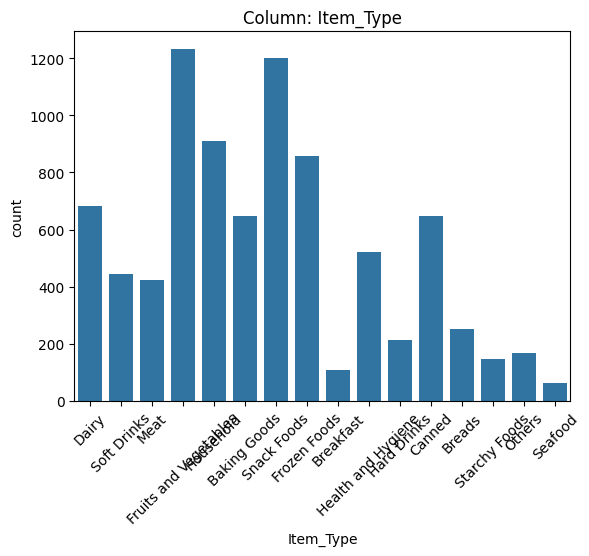

NaN's Found: 0
Unique Values: 16


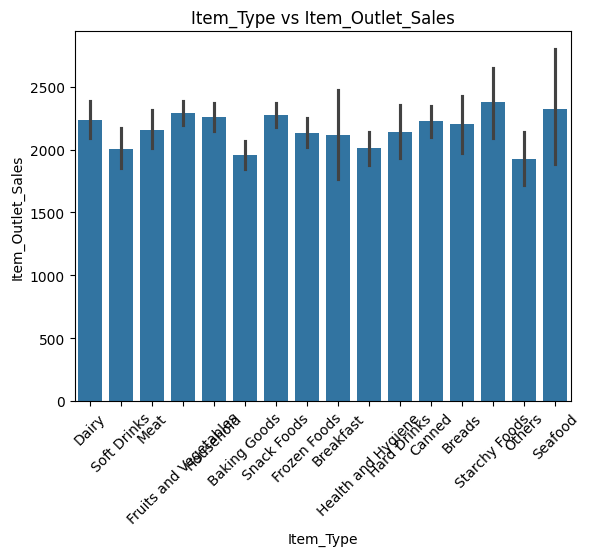

In [37]:
explore_categorical(df, 'Item_Type')
plot_categorical_vs_target(df, 'Item_Type', y='Item_Outlet_Sales')

### Feature Observations:

- Type:
  Categorical (Nominal)

- Null values:
  No missing values (0%).

- Handling null values:
  No action needed.

- Constant or quasi-constant:
  No, the feature contains multiple categories with varied distribution.

- Cardinality:
  Moderate (16 unique categories)

- Known before target?
  Yes, item type is known before sales occur.

- Business reason to exclude?
  No, product category is an important factor that influences customer demand and sales.

### Feature vs Target Observations:

- Expected to predict target?
  Yes, different product categories are expected to have different sales patterns.

- Does it appear to be a predictor?
  Yes, moderate predictor.

- Explanation:
  The bar plot shows variation in average sales across different item types.
  Some categories like Seafood and Starchy Foods appear to have higher sales,
  while others like Breakfast and Baking Goods have relatively lower sales.
  This indicates that Item_Type has a noticeable impact on Item_Outlet_Sales.

Item_Type is a meaningful feature and should definitely be included in the model as it captures consumer preferences across product categories.

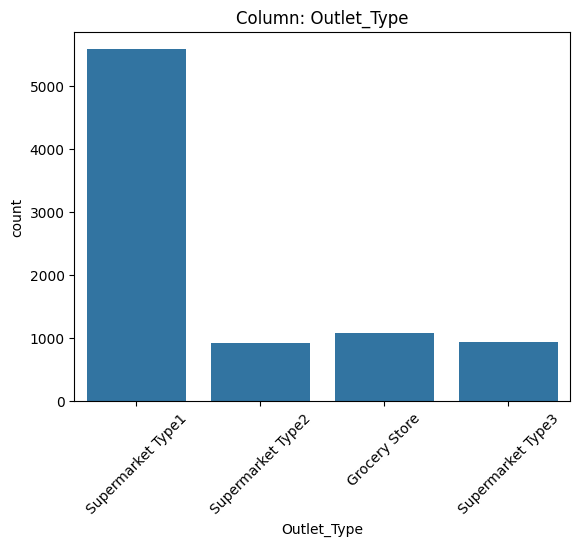

NaN's Found: 0
Unique Values: 4


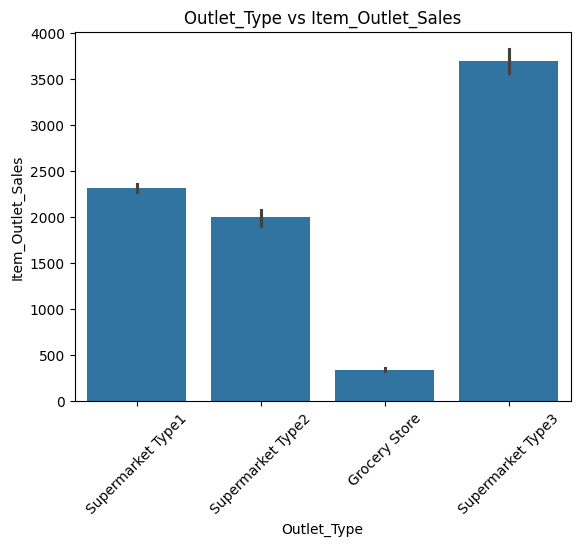

In [38]:
# Univariate
explore_categorical(df, 'Outlet_Type')

# Multivariate
plot_categorical_vs_target(df, 'Outlet_Type', y='Item_Outlet_Sales')

### Feature Observations:

- Type:
  Categorical (Nominal)

- Null values:
  No missing values (0%).

- Handling null values:
  No action needed.

- Constant or quasi-constant:
  No, there are multiple categories with different frequencies.

- Cardinality:
  Low (4 unique values)

- Known before target?
  Yes, outlet type is known before sales occur.

- Business reason to exclude?
  No, outlet type is an important factor that affects sales performance.

### Feature Observations:

- Type:
  Categorical (Nominal)

- Null values:
  No missing values (0%).

- Handling null values:
  No action needed.

- Constant or quasi-constant:
  No, there are multiple categories with different frequencies.

- Cardinality:
  Low (4 unique values)

- Known before target?
  Yes, outlet type is known before sales occur.

- Business reason to exclude?
  No, outlet type is an important factor that affects sales performance.

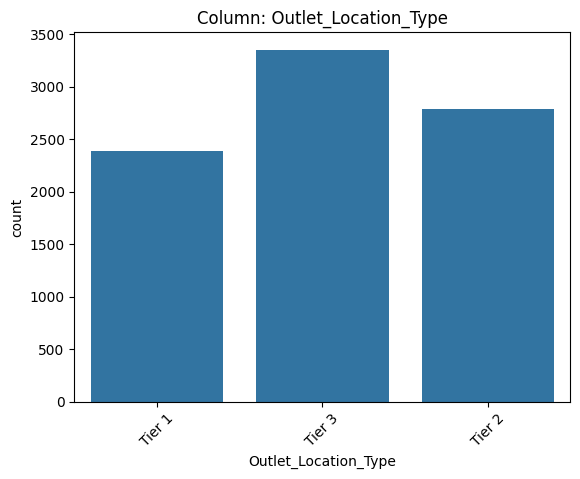

NaN's Found: 0
Unique Values: 3


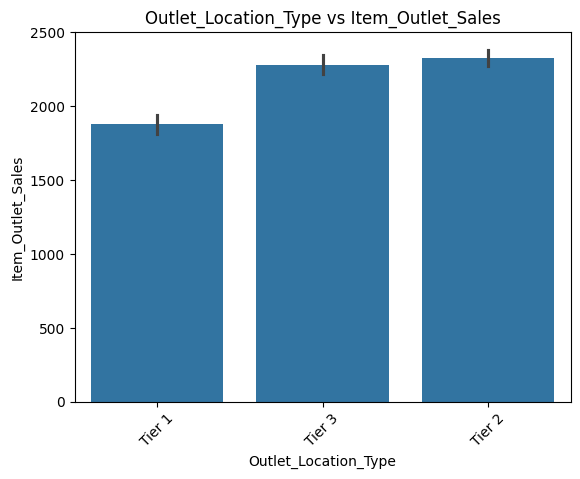

In [39]:
explore_categorical(df, 'Outlet_Location_Type')
plot_categorical_vs_target(df, 'Outlet_Location_Type', y='Item_Outlet_Sales')

### Feature Observations:

- Type:
  Categorical (Ordinal)

- Null values:
  No missing values (0%).

- Handling null values:
  No action needed.

- Constant or quasi-constant:
  No, there are multiple categories with balanced distribution.

- Cardinality:
  Low (3 unique values: Tier 1, Tier 2, Tier 3)

- Known before target?
  Yes, outlet location is known before sales occur.

- Business reason to exclude?
  No, location type is an important factor influencing customer behavior and sales.

### Feature vs Target Observations:

- Expected to predict target?
  Yes, different location tiers are expected to affect sales.

- Does it appear to be a predictor?
  Yes, moderate predictor.

- Explanation:
  The plot shows that Tier 2 and Tier 3 locations have higher average sales compared to Tier 1.
  This indicates that location plays a role in sales performance.
  However, the difference between Tier 2 and Tier 3 is not very large, suggesting a moderate impact.

Outlet_Location_Type has a noticeable effect on sales and should be included as a feature in the model.

Project 1 - Part 5

In [40]:
import pandas as pd
from sklearn import set_config
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

In [41]:
# set output as pandas
set_config(transform_output="pandas")

In [42]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,NaN,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,NaN,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


CLEANING BEFORE SPLIT

In [43]:
# remove duplicates
df = df.drop_duplicates()

# fix inconsistent categories
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

# drop high-cardinality column
df = df.drop(columns='Item_Identifier')



DEFINE X AND y

In [44]:
y = df['Item_Outlet_Sales']
X = df.drop(columns='Item_Outlet_Sales')

TRAIN TEST SPLIT

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42
)


DEFINE COLUMN TYPES

In [47]:
num_cols = X_train.select_dtypes(include='number').columns
cat_cols = X_train.select_dtypes(include='object').columns


CREATE PIPELINES

In [48]:
# numeric pipeline
num_pipe = make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
)

# categorical pipeline
cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown='ignore', sparse_output=False)
)


CREATE COLUMN TRANSFORMER

In [49]:
col_transformer = ColumnTransformer(
    transformers=[
        ('num', num_pipe, num_cols),
        ('cat', cat_pipe, cat_cols)
    ],
    verbose_feature_names_out=False
)


FIT ON TRAINING DATA

In [50]:
col_transformer.fit(X_train)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('standardscaler',
                                                  StandardScaler())]),
                                 Index(['Item_Weight', 'Item_Visibility', 'Item_MRP',
       'Outlet_Establishment_Year'],
      dtype='object')),
                                ('cat',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 Index(['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type'],
      dtype='object'))],
                  verbose_feature_names_out=False)

TRANSFORM DATA

In [51]:
X_train_processed = col_transformer.transform(X_train)
X_test_processed = col_transformer.transform(X_test)


CHECK RESULTS

In [52]:
# check datatypes (should be all numeric)
print(X_train_processed.dtypes)

# check scaling (mean ≈ 0, std ≈ 1)
print(X_train_processed.describe())

# preview data
print(X_train_processed.head())
print(X_test_processed.head())

Item_Weight                        float64
Item_Visibility                    float64
Item_MRP                           float64
Outlet_Establishment_Year          float64
Item_Fat_Content_Low Fat           float64
Item_Fat_Content_Regular           float64
Item_Type_Baking Goods             float64
Item_Type_Breads                   float64
Item_Type_Breakfast                float64
Item_Type_Canned                   float64
Item_Type_Dairy                    float64
Item_Type_Frozen Foods             float64
Item_Type_Fruits and Vegetables    float64
Item_Type_Hard Drinks              float64
Item_Type_Health and Hygiene       float64
Item_Type_Household                float64
Item_Type_Meat                     float64
Item_Type_Others                   float64
Item_Type_Seafood                  float64
Item_Type_Snack Foods              float64
Item_Type_Soft Drinks              float64
Item_Type_Starchy Foods            float64
Outlet_Identifier_OUT010           float64
Outlet_Iden